# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнил(а):

**Дудий Эльвира** 😀

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [4]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [5]:
RANDOM_STATE = 42

In [6]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

**Фиксируем сиды в ноутбуке, чтобы результаты эксперимента всегда повторялись. Иначе каждый запуск обучения будет давать разные цифры например из-за случайной инициализации весов, перемешивания данных и невозможно понять, реально ли ты улучшил модель или просто так повезло с очередным случайным значением.**

## Часть 1 | EDA




Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [7]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [8]:
# @title
# Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
print(df_train.isna().sum())


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          202
engine           202
max_power        196
torque           203
seats            202
dtype: int64


In [9]:
# @title
arr=[]
for col in df_train.columns:
  num=df_train[col].isna().sum()
  if num > 0:
    arr.append((col, num))
print('Колонки с пропусками:')
print('==='*10)
for col, num in arr:
  print('---'*10)
  print(f'{col}: {num}')



Колонки с пропусками:
------------------------------
mileage: 202
------------------------------
engine: 202
------------------------------
max_power: 196
------------------------------
torque: 203
------------------------------
seats: 202


In [10]:
# @title
 # Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
print('---'*10)
print( f'Всего дупликатов: {df_train.duplicated().sum()}')
print('---'*10)

------------------------------
Всего дупликатов: 985
------------------------------


In [11]:
# @title
#  Постройте дашборд в одну строку, используя ydata-profilling (0.15 балла)

!pip install ydata-profiling
import ydata_profiling
from ydata_profiling import ProfileReport

In [12]:
# @title
ProfileReport(df_train, minimal=True).to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 28.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### **GitHub не показывает интерактивные виджеты ydata-profiling, поэтому сохраняем отчёт в отдельный HTML файл**
### **Откройте ydata_report.html в браузере (файл лежит в репозитории)**

In [13]:
# GitHub не показывает интерактивные виджеты ydata-profiling,
# поэтому сохраняем отчёт в отдельный HTML файл
# Откройте ydata_report.html в браузере(файл лежит в репозитории)
!pip install ydata-profiling -q
from ydata_profiling import ProfileReport
profile = ProfileReport(df_train, minimal=True)
profile.to_file("ydata_report.html")

from IPython.display import HTML
HTML('<a href="ydata_report.html" target="_blank">📊 Открыть полный отчёт в новой вкладке</a>')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 64.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Вывод:

**1. Половина машин 2014 года или новее.**

**2. Цены от 30 тысяч до 10 миллионов, но большинство машин стоят около 450 тысяч. Дорогие авто поднимают среднюю цену до 640 тысяч.**

**3. Пробег в среднем 60 000 км, есть редкие экземпляры с пробегом более 2 миллионов км.**

**4. Топливо почти поровну: дизель 54% и бензин 44%, газ встречается редко.**

**5. Большинство продавцов частные лица 83%.**

**6. Коробка передач в основном механическая 87%, автомат только у 13% машин.**

**7. Пропуски есть в колонках mileage, engine, max_power, torque, seats, но их всего около 2 3%. Данные в этих колонках текстовые с единицами измерения, кроме seats где числа.**

### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [ ]:
# @title
#  Посчитайте основные статистики по числовым столбцам для трейна и теста
print('---'*20)
print('⚫ Oсновные статистики по числовым столбцам')
print('---'*20)
print('Треннировочные данные:')
print('==='*20)
print(f'{df_train.describe()}')
print('---'*20)
print('Тестовые данные:')
print('==='*20)
print(f'{df_test.describe()}')
print('---'*20)

------------------------------------------------------------
⚫ Oсновные статистики по числовым столбцам
------------------------------------------------------------
Треннировочные данные:
              year  selling_price     km_driven        seats
count  6999.000000   6.999000e+03  6.999000e+03  6797.000000
mean   2013.818403   6.395152e+05  6.958462e+04     5.419008
std       4.053095   8.089419e+05  5.772400e+04     0.965767
min    1983.000000   2.999900e+04  1.000000e+00     2.000000
25%    2011.000000   2.549990e+05  3.500000e+04     5.000000
50%    2015.000000   4.500000e+05  6.000000e+04     5.000000
75%    2017.000000   6.750000e+05  9.700000e+04     5.000000
max    2020.000000   1.000000e+07  2.360457e+06    14.000000
------------------------------------------------------------
Тестовые данные:
              year  selling_price      km_driven       seats
count  1000.000000   1.000000e+03    1000.000000  981.000000
mean   2013.681000   6.179010e+05   71393.341000    5.410805
st

In [ ]:
# @title
# Посчитайте основные статистики по категориальным столбцам для трейна и теста
print('---'*25)
print('⚫ Oсновные статистики по категориальным столбцам')
print('---'*25)
print('Треннировочные данные:')
print('==='*25)
print(f'{df_train.describe(include=['object'])}')
print('---'*25)
print('Тестовые данные:')
print('==='*25)
print(f'{df_test.describe(include=['object'])}')
print('---'*25)


---------------------------------------------------------------------------
⚫ Oсновные статистики по категориальным столбцам
---------------------------------------------------------------------------
Треннировочные данные:
                          name    fuel seller_type transmission        owner  \
count                     6999    6999        6999         6999         6999   
unique                    1924       4           3            2            5   
top     Maruti Swift Dzire VDI  Diesel  Individual       Manual  First Owner   
freq                       116    3793        5826         6095         4587   

          mileage   engine max_power          torque  
count        6797     6797      6803            6796  
unique        386      120       316             419  
top     18.9 kmpl  1248 CC    74 bhp  190Nm@ 2000rpm  
freq          197      885       330             468  
---------------------------------------------------------------------------
Тестовые данные:
       

In [ ]:
# @title
# Сравните среднее и медиану внутри train, внутри test и между собой. О чём могут говорить результаты?

for col in ['year', 'selling_price', 'km_driven', 'seats']:
  print('==='*15)
  print(f'⚫ {col}')
  print('==='*15)
  print('Треннировочные данные:')
  print(f'mean={df_train[col].mean():.3f}, median={df_train[col].median():.3f}')
  print('---'*15)
  print('Тестовые данные:')
  print(f'mean={df_test[col].mean():.3f}, median={df_test[col].median():.3f}')
  print('---'*15)
  print(f"Разница mean-train vs mean-test: {df_train[col].mean() - df_test[col].mean():.3f}")
  print(f"Разница median-train vs median-test: {df_train[col].median() - df_test[col].median()}")


⚫ year
Треннировочные данные:
mean=2013.818, median=2015.000
---------------------------------------------
Тестовые данные:
mean=2013.681, median=2014.000
---------------------------------------------
Разница mean-train vs mean-test: 0.137
Разница median-train vs median-test: 1.0
⚫ selling_price
Треннировочные данные:
mean=639515.197, median=450000.000
---------------------------------------------
Тестовые данные:
mean=617901.042, median=434999.000
---------------------------------------------
Разница mean-train vs mean-test: 21614.155
Разница median-train vs median-test: 15001.0
⚫ km_driven
Треннировочные данные:
mean=69584.616, median=60000.000
---------------------------------------------
Тестовые данные:
mean=71393.341, median=61500.000
---------------------------------------------
Разница mean-train vs mean-test: -1808.725
Разница median-train vs median-test: -1500.0
⚫ seats
Треннировочные данные:
mean=5.419, median=5.000
---------------------------------------------
Тестовые данн

✅ Вывод:
**Train и test похожи. Внутри выборок цена и пробег имеют выбросы. В train выбросы сильнее. Год и места почти без выбросов. Различия между train и test небольшие, тест репрезентативен.**

### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [ ]:
# @title
# Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
# Отобразите такие объекты (0.05 балла)
features=df_train.drop('selling_price', axis=1)
duplicated_count = features.duplicated().sum()
duplicated_rows = features[features.duplicated(keep=False)]
print('---'*25)
print(f'⚫ Всего уникальных дубликатов: {duplicated_count}')
print('---'*25)
print(f"⚫ Всего строк, участвующих в дубликатах: {len(duplicated_rows)}")
print('---'*25)
print(f' {duplicated_rows}')
print('---'*25)

---------------------------------------------------------------------------
⚫ Всего уникальных дубликатов: 1159
---------------------------------------------------------------------------
⚫ Всего строк, участвующих в дубликатах: 1799
---------------------------------------------------------------------------
                                           name  year  km_driven    fuel  \
22                     Maruti Baleno Delta 1.2  2016      45000  Petrol   
26                 Maruti Omni E MPI STD BS IV  2018      25000  Petrol   
27             Maruti Vitara Brezza LDi Option  2017      70000  Diesel   
28                          Fiat Palio 1.2 ELX  2003      50000  Petrol   
29                   Maruti Omni 8 Seater BSIV  2012      35000  Petrol   
...                                        ...   ...        ...     ...   
6981  Ford Freestyle Titanium Plus Diesel BSIV  2018      24000  Diesel   
6984  Ford Freestyle Titanium Plus Diesel BSIV  2018      24000  Diesel   
6989          

In [ ]:
# @title
# Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
#  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)
features_cols=[col for col in df_train if col!='selling_price']
df_train=df_train.drop_duplicates(subset=features_cols, keep='first').reset_index(drop=True)
print(f"⚫ Финальный размер выборки: {df_train.shape}")

⚫ Финальный размер выборки: (5840, 13)


In [ ]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [ ]:
# @title
# Уберите единицы измерения для признаков mileage, engine, max_power.
# Приведите тип данных к float.

# train
df_train['mileage'] = df_train['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df_train['engine'] = df_train['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df_train['max_power'] = df_train['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,113.75nm@ 4000rpm,5.0


In [ ]:
# @title
#test
df_test['mileage'] = df_test['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['engine'] = df_test['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['max_power'] = df_test['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0,2498.0,112.0,260 Nm at 1800-2200 rpm,7.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5,1497.0,108.5,260Nm@ 1500-2750rpm,5.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9,1799.0,130.0,172Nm@ 4300rpm,5.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1,1498.0,98.6,200Nm@ 1750rpm,5.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5,1172.0,65.0,96 Nm at 3000 rpm,5.0


In [ ]:
# @title
# Предобработайте признак torque — разделите его на два: собственно torque и max_torque_rpm. Учтите единицы измерения
import re
def last_number(s):
    if pd.isna(s):
        return None
    nums = re.findall(r'\d+\.?\d*', str(s))
    return float(nums[-1]) if nums else None

df_train['max_torque_rpm']=df_train['torque'].apply(last_number)
df_test['max_torque_rpm']=df_test['torque'].apply(last_number)

df_train['torque']=df_train['torque'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['torque']=df_test['torque'].str.extract(r'(\d+\.?\d*)').astype(float)


In [ ]:
df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_torque_rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.00,5.0,2000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.00,5.0,2500.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.40,5.0,2750.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.50,5.0,500.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,113.75,5.0,4000.0


In [ ]:
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_torque_rpm
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0,2498.0,112.0,260.0,7.0,2200.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5,1497.0,108.5,260.0,5.0,2750.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9,1799.0,130.0,172.0,5.0,4300.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1,1498.0,98.6,200.0,5.0,1750.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5,1172.0,65.0,96.0,5.0,3000.0


### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [ ]:
# @title
# Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
cols=['mileage', 'engine', 'max_power', 'seats', 'torque', 'max_torque_rpm']
medians=df_train[cols].median()
df_train[cols]=df_train[cols].fillna(medians)
df_test[cols]=df_test[cols].fillna(medians)

print("⚫ Пропуски в train:", df_train[cols].isna().sum().sum())
print("⚫ Пропуски в test:", df_test[cols].isna().sum().sum())

⚫ Пропуски в train: 0
⚫ Пропуски в test: 0


 ✅*Почему стоит применять именно медиану. Могли ли мы применить среднее Обоснуйте свое рассуждение.*

 Ответ:
***Медиана устойчива к выбросам, а среднее сильно искажается из‑за них. Поэтому медиана лучше подходит для заполнения пропусков в таких данных. Применить среднее можно, но нежелательно.Оно будет нерепрезентативным из‑за выбросов.***


✅ *Как правильно считать медиану для заполнения?*

 Ответ:
***Медиану нужно вычислить только на тренировочной выборке, без целевой переменной. Затем этой же медианой заполнить пропуски и в `train` и в `test`.  Статистика вычисляется только по тренировочным данным, чтобы избежать «подглядывания» в тест и не создавать искусственную зависимость.***

✅ Ответ:  **По тренировочным данным для `train` и `test`**



### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [ ]:
# @title
# Осуществите приведение столбцов к необходимому типу.
df_train['engine']=df_train['engine'].astype(int)
df_test['engine']=df_test['engine'].astype(int)
df_train['seats']=df_train['seats'].astype(int)
df_test['seats']=df_test['seats'].astype(int)

In [ ]:
print(df_train['seats'].unique())

[ 5  4  7  8  6  9 10 14  2]


 ✅ Ответье на вопрос — *почему (хоть мы этого и не делаем) seats, возможно рассмотреть как категориальную переменную?*

Ответ: **Потому что `seats` принимает мало уникальных значений [ 5  4  7  8  6  9 10 14  2]. Это не непрерывная величина, а фиксированные категории.**

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [ ]:
# @title
# Снова вызовите метод describe и проанализируйте статистики.
print('---'*20)
print('⚫ Oсновные статистики по числовым столбцам')
print('---'*20)
print('Треннировочные данные:')
print('==='*20)
print(f'{df_train.describe()}')
print('---'*20)
print('Тестовые данные:')
print('==='*20)
print(f'{df_test.describe()}')
print('---'*20)

------------------------------------------------------------
⚫ Oсновные статистики по числовым столбцам
------------------------------------------------------------
Треннировочные данные:
              year  selling_price     km_driven      mileage       engine  \
count  5840.000000   5.840000e+03  5.840000e+03  5840.000000  5840.000000   
mean   2013.428425   5.229601e+05  7.395224e+04    19.430841  1429.448973   
std       4.095622   5.354320e+05  6.007114e+04     3.985973   485.662834   
min    1983.000000   2.999900e+04  1.000000e+00     0.000000   624.000000   
25%    2011.000000   2.500000e+05  3.900000e+04    16.950000  1197.000000   
50%    2014.000000   4.050000e+05  7.000000e+04    19.370000  1248.000000   
75%    2017.000000   6.400000e+05  1.000000e+05    22.300000  1498.000000   
max    2020.000000   1.000000e+07  2.360457e+06    42.000000  3604.000000   

         max_power       torque        seats  max_torque_rpm  
count  5840.000000  5840.000000  5840.000000     5840.0

✅ *Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?*

Ответ:
**Заполнение медианой не сдвинуло распределения, так как пропусков было мало,около 3%, а медиана устойчива к выбросам. Средние значения до и после остались почти одинаковыми.**

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

<Figure size 1200x800 with 0 Axes>

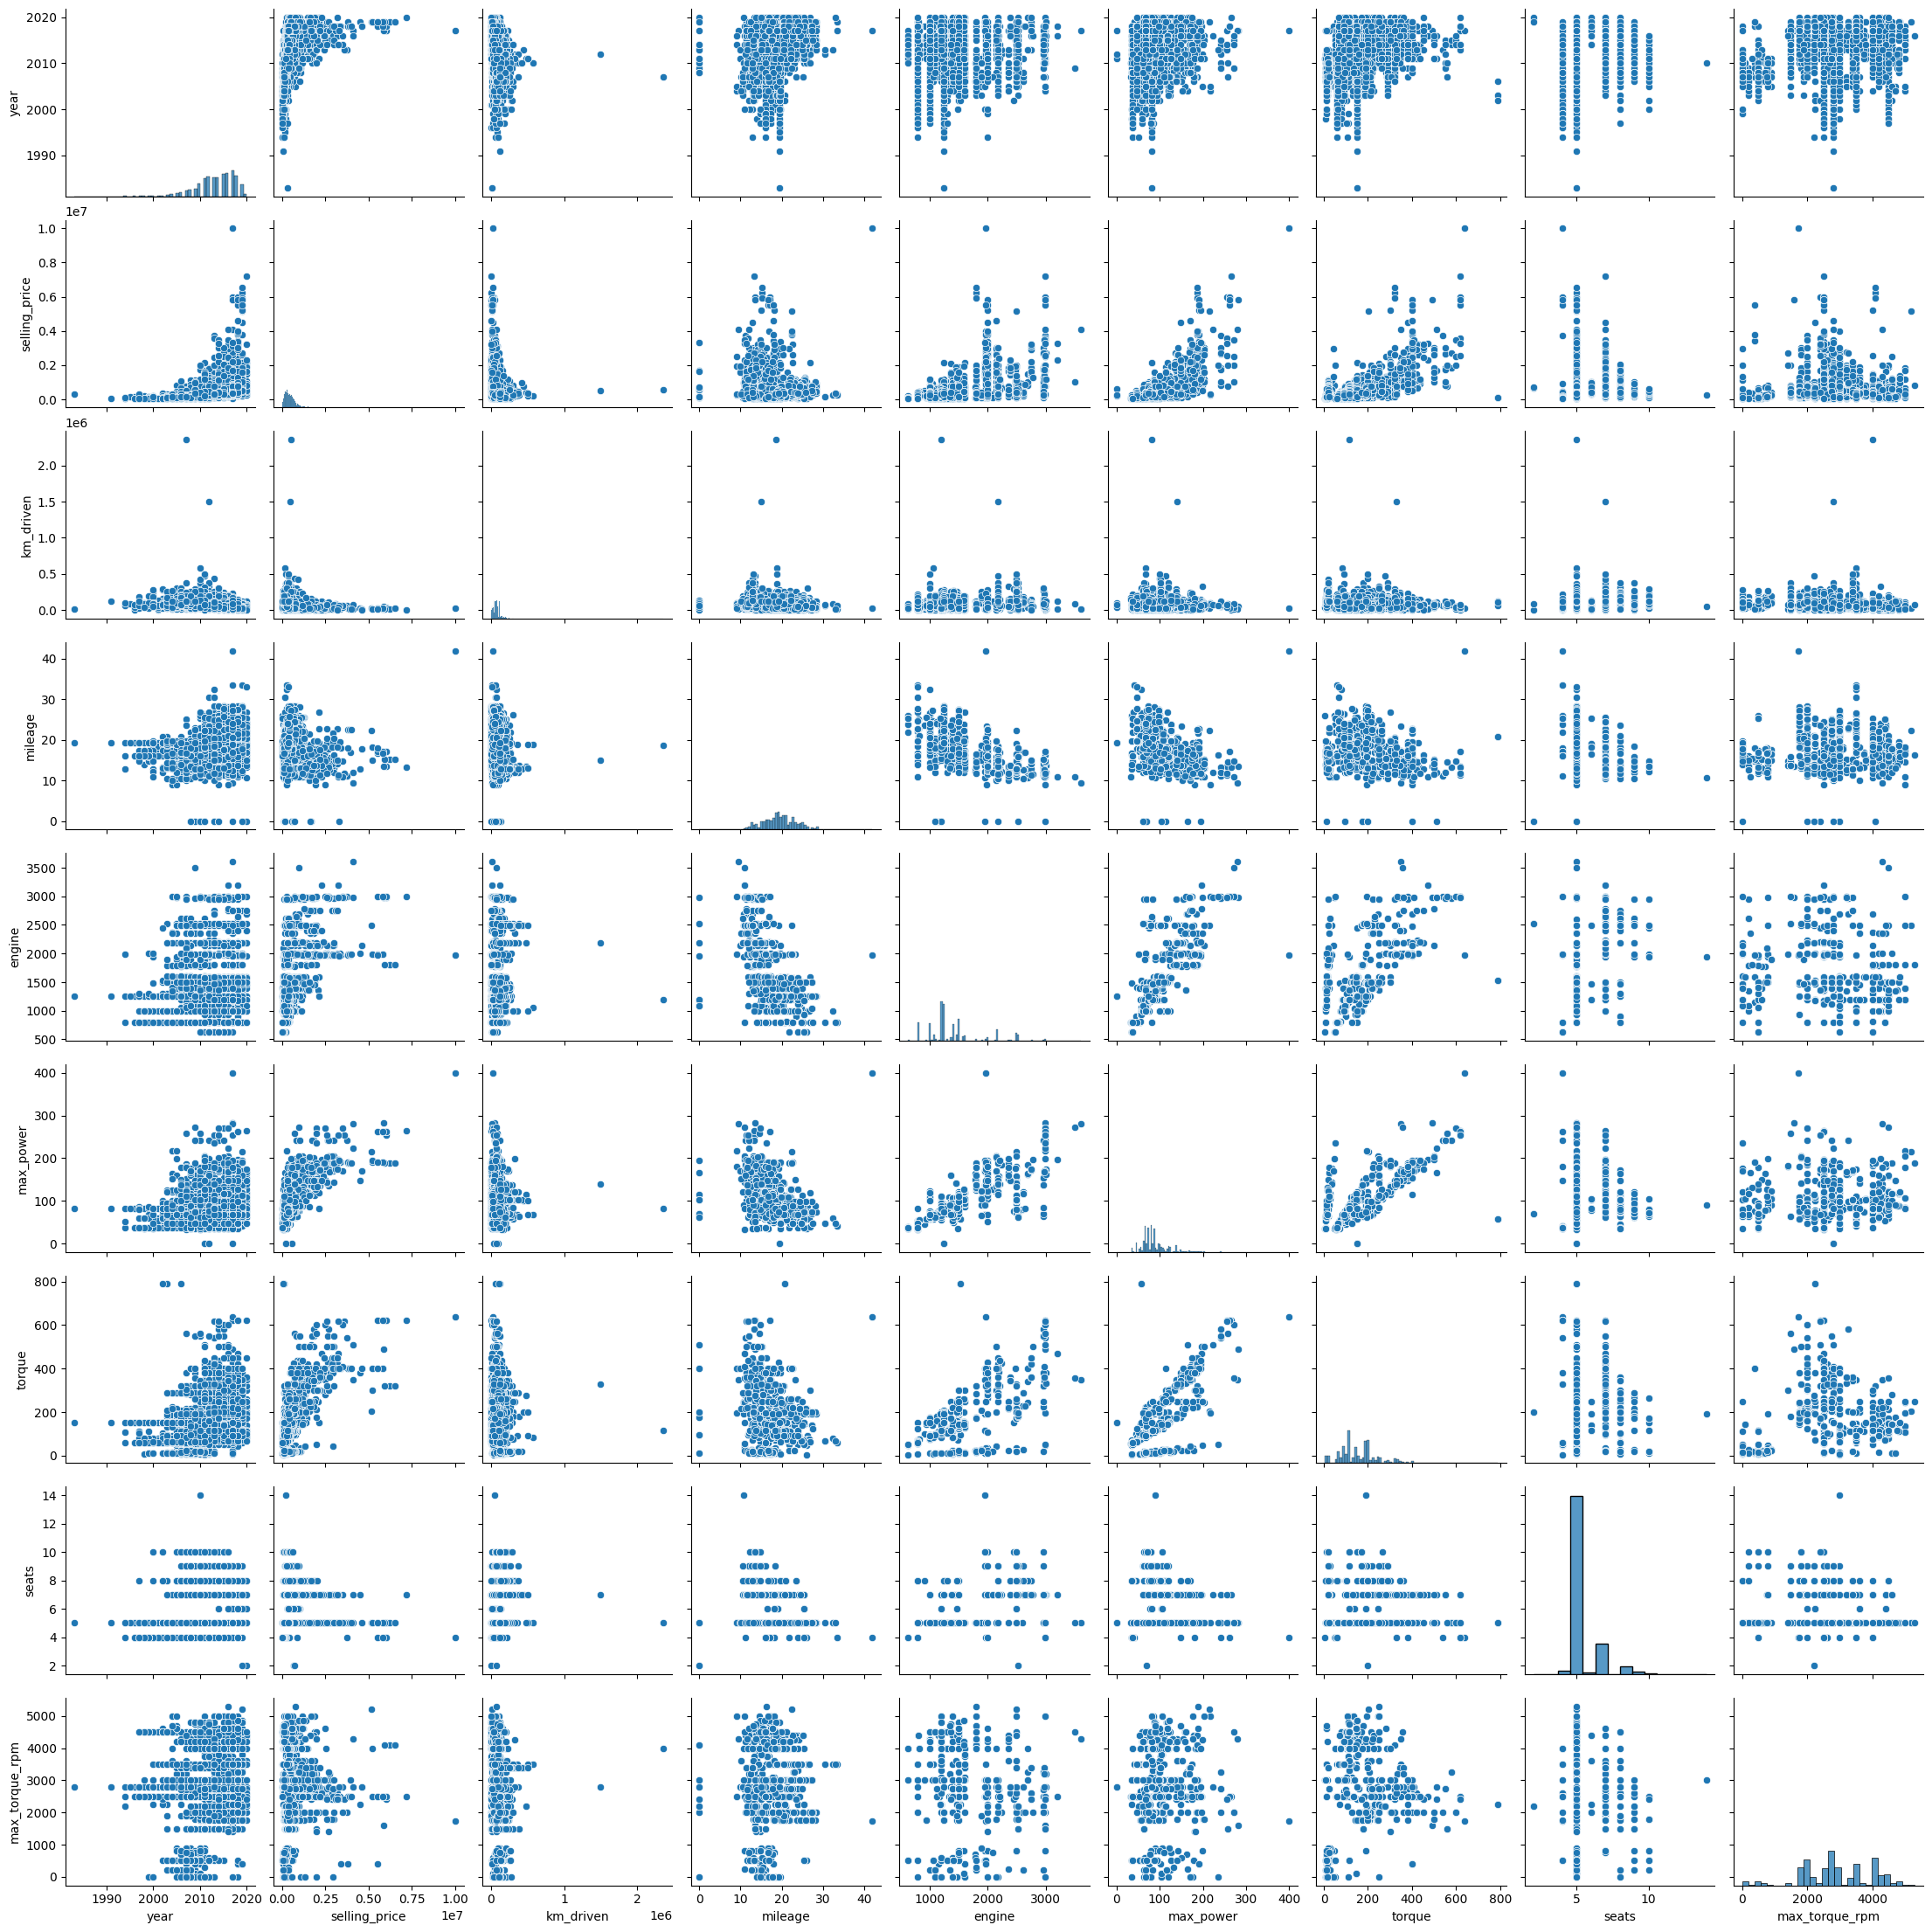

In [ ]:
# @title
# Воспользуйтесь pairplot из библиотеки seabron, чтобы визуализировать попарные распределения числовых признаков для train
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(12,8))
numeric_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine',
                'max_power', 'torque', 'seats', 'max_torque_rpm']

sns.pairplot(df_train[numeric_cols], diag_kind='hist')
plt.show()

 ✅ По полученному графику ответьте на вопросы:

*Можно ли предположить на основе распределений связь признаков с целевой переменной?*

*Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?*

Ответ: **Да, можно.**

**Связь признаков с ценой:**  
На основе распределений видно, что мощность, момент, объём двигателя и год выпуска имеют заметную связь с ценой. Пробег и расход топлива влияют слабо, а обороты максимального момента практически не влияют.

**Корреляции между признаками:**  
По распределениям можно предположить, что мощность, момент, объём двигателя и количество мест связаны между собой. У машин с большим объёмом двигателя обычно выше расход топлива. Эти предположения подтверждаются числовыми корреляциями.

<Figure size 1200x800 with 0 Axes>

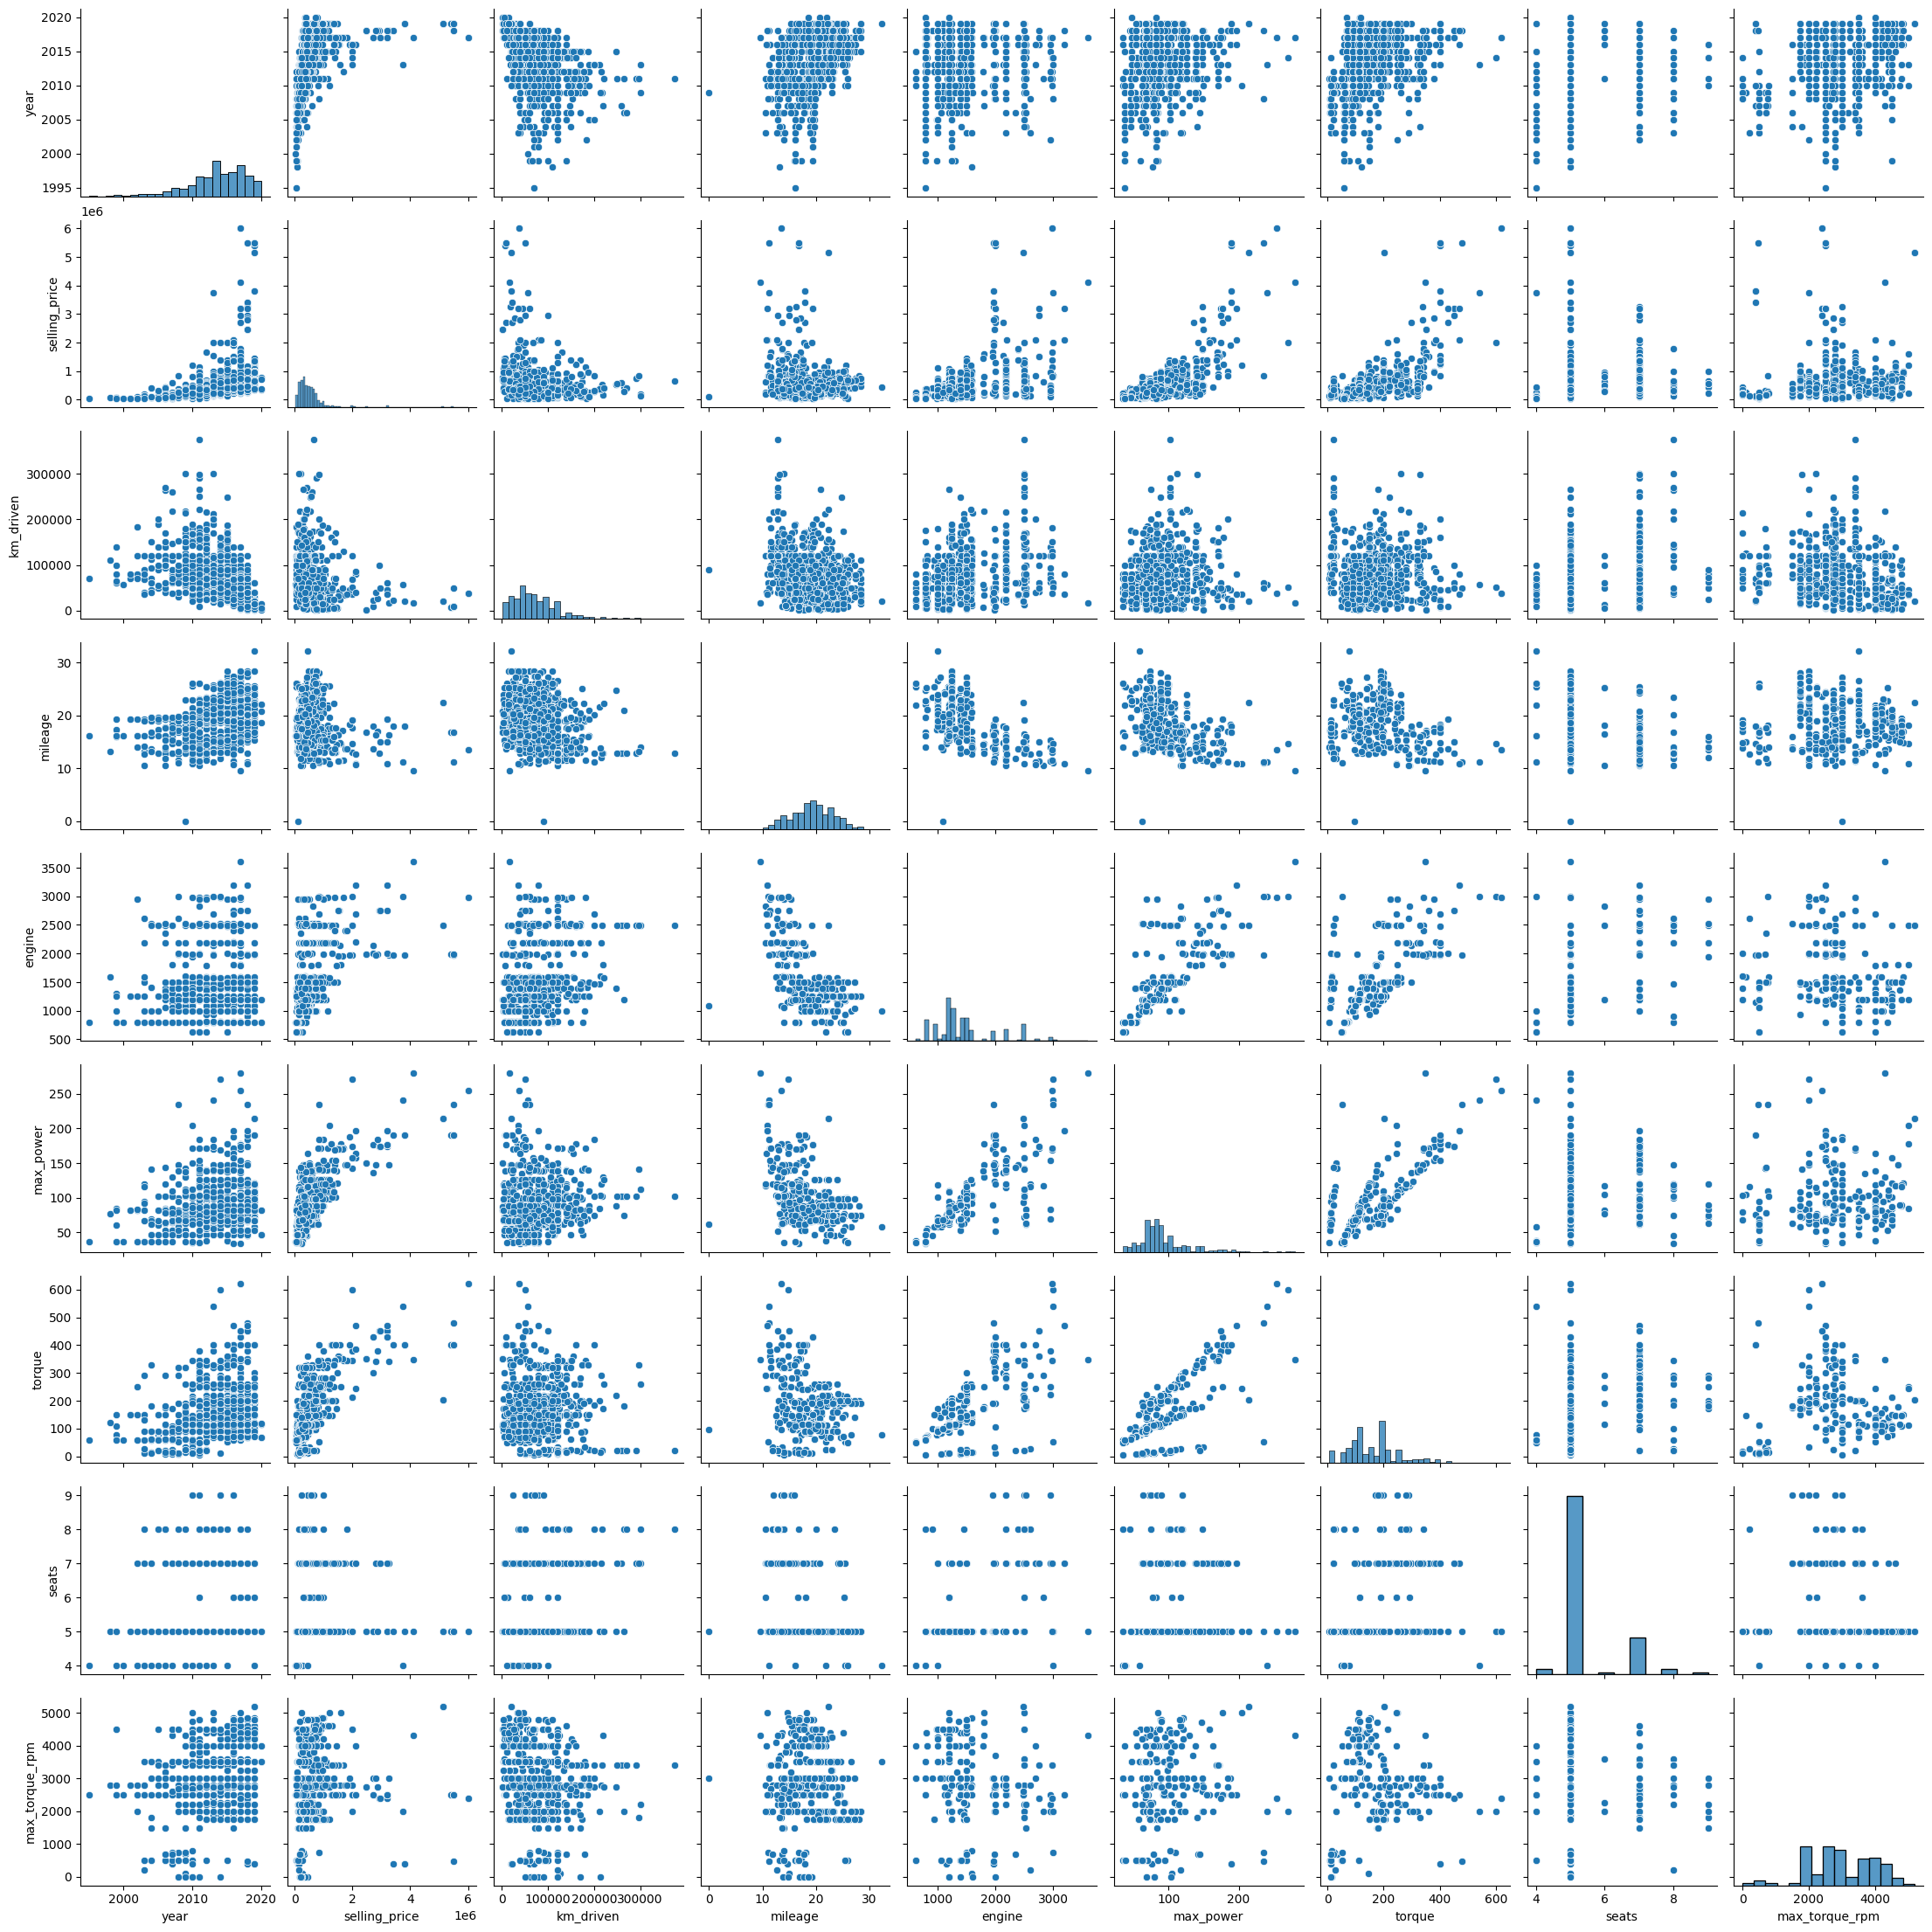

In [ ]:
# @title
# Постройте pairplot по тестовым данным

plt.figure(figsize=(12,8))
numeric_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine',
                'max_power', 'torque', 'seats', 'max_torque_rpm']

sns.pairplot(df_test[numeric_cols], diag_kind='hist')
plt.show()


   ✅ Ответьте на вопрос "*Похожими ли оказались совокупности при разделении на трейн и тест?"*

   Ответ:  **Умеренно похожи. В трейне и тесте картина одна и та же: цена зависит от мощности, момента и объёма, а пробег и расход почти не влияют. Между признаками тоже те же связи: большая машина значит мощнее. Разница совсем маленькая, так что тест хорошо отражает трейн.**

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

In [ ]:
# @title
# Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи pd.corr()
corr_matrix = df_train.corr(numeric_only=True)
print('==='*15)
print("⚫ Значения коэффициента корреляции Пирсона")
print('---'*15)
print(corr_matrix['selling_price'].sort_values(ascending=False))
print('---'*15)

⚫ Значения коэффициента корреляции Пирсона
---------------------------------------------
selling_price     1.000000
max_power         0.692814
torque            0.613397
engine            0.447672
year              0.427279
seats             0.149953
max_torque_rpm   -0.007473
mileage          -0.104769
km_driven        -0.164828
Name: selling_price, dtype: float64
---------------------------------------------


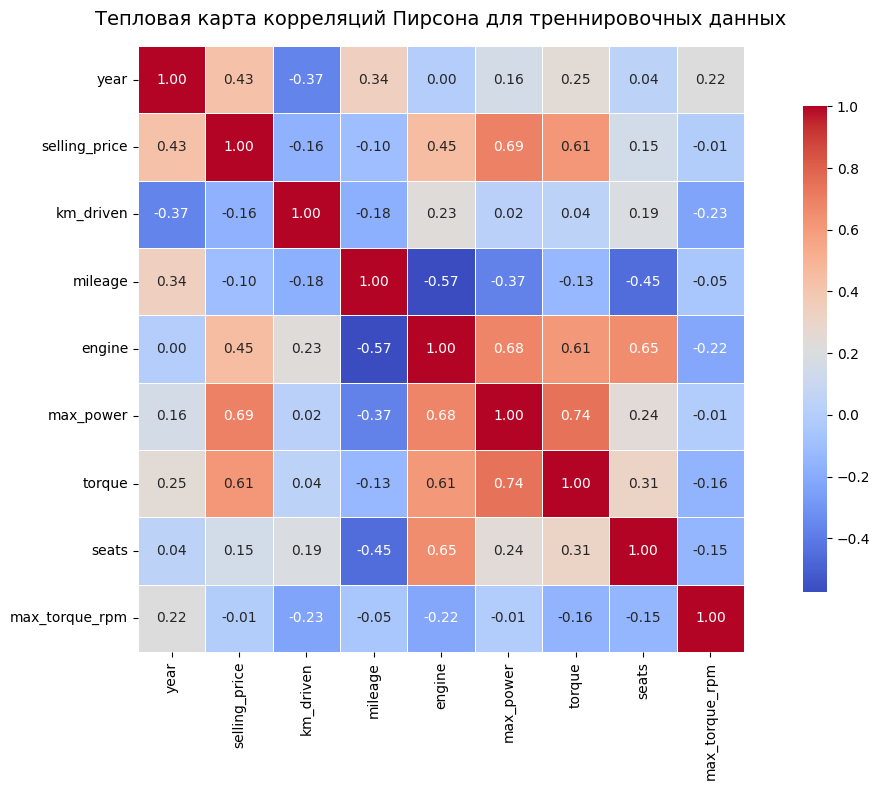

In [ ]:
# @title
# По полученным корреляциям постройте тепловую карту (heatmap из бибилотеки seaborn)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляций Пирсона для треннировочных данных', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

✅ *Какие 2 признака наименее скоррелированы между собой?*

Ответ:  `mileage` и `engine` с корреляцией `-0.57` **умеренная отрицательная связь**.

✅ *Между какими наблюдается довольно сильная положительная линейная зависимость?*

Ответ:  Между `max_power` и `torque`  корреляция `0.74` **сильная положительная связь.**

✅ *Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?*

Ответ:  **Да, верно.** Корреляция `year` и `km_driven` равна `-0.37`  **отрицательная**: старые машины  действительно имеют больший пробег.

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ]

Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


In [ ]:
!pip install phik -q

⚫ Сравнение корреляции Спирмена:
max_power и torque:
 Корреляция через numpy: 0.668
 Корреляция через библиотеку: 0.669

engine и max_power:
 Корреляция через numpy: 0.711
 Корреляция через библиотеку: 0.713

year и km_driven:
 Корреляция через numpy: -0.567
 Корреляция через библиотеку: -0.570

Матрица корреляции phik
interval columns not set, guessing: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']
                 year  selling_price  km_driven  mileage  engine  max_power  \
year            1.000          0.220      0.082    0.279   0.213      0.382   
selling_price   0.220          1.000      0.000    0.650   0.504      0.872   
km_driven       0.082          0.000      1.000    0.082   0.211      0.000   
mileage         0.279          0.650      0.082    1.000   0.588      0.687   
engine          0.213          0.504      0.211    0.588   1.000      0.721   
max_power       0.382          0.872      0.000    0.687   

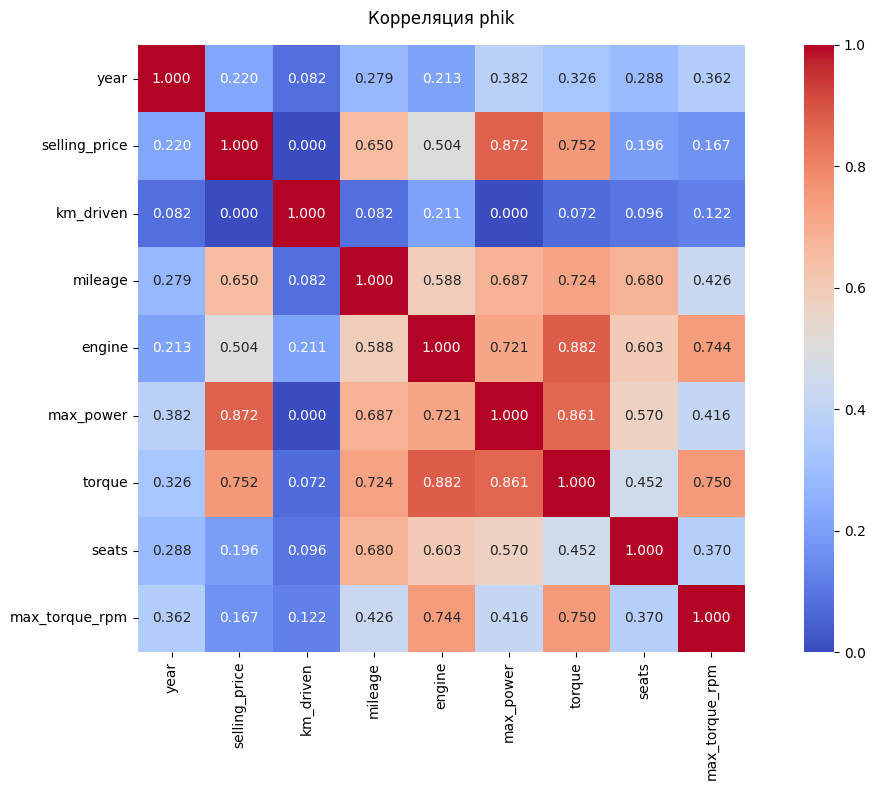

In [ ]:
# @title
# Реализуйте корреляцию Спирмена без использования библиотек (можно пользоваться только numpy).
from scipy.stats import spearmanr

def spearman_corr(x, y):
    x_rank = np.argsort(np.argsort(x))
    y_rank = np.argsort(np.argsort(y))
    x_centered = x_rank - x_rank.mean()
    y_centered = y_rank - y_rank.mean()
    numerator = (x_centered * y_centered).sum()
    denominator = np.sqrt((x_centered**2).sum() * (y_centered**2).sum())
    return numerator / denominator

numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

#Сравните результаты вычисления с библиотечной реализацией
print('==='*15)
print("⚫ Сравнение корреляции Спирмена:")
print('==='*15)

pairs = [('max_power', 'torque'), ('engine', 'max_power'), ('year', 'km_driven')]

for col1, col2 in pairs:
    my_corr = spearman_corr(df_train[col1].values, df_train[col2].values)
    lib_corr = spearmanr(df_train[col1], df_train[col2])[0]
    print(f"{col1} и {col2}:")
    print(f" Корреляция через numpy: {my_corr:.3f}")
    print(f" Корреляция через библиотеку: {lib_corr:.3f}")
    print()

#Постройте матрицу корреляции phik
import phik

print("Матрица корреляции phik")
phik_matrix = phik.phik_matrix(df_train[numeric_cols])  # только один раз
print(phik_matrix.round(3))


plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.3f', cmap='coolwarm', square=True)

print('==='*15)
plt.title('Корреляция phik', pad=15)
print('==='*15)

plt.tight_layout()
plt.show()




✅ **1. Реализация Спирмена через numpy**

Моя функция считает почти так же, как библиотечная, расхождения совсем маленькие.

Мощность и крутящий момент связаны довольно сильно: чем мощнее двигатель, тем выше момент. Объём двигателя тоже связан с мощностью. А ещё старые машины ожидаемо имеют больший пробег.

✅ **2. Что показал phik**

Эта матрица показывает, насколько признаки связаны между собой

**Что сильнее всего влияет на цену:**
- мощность
- момент
- расход топлива
- объём двигателя.

**Что почти не влияет на цену:**
пробег. По цифрам он вообще не связан с ценой, что немного неожиданно. Обороты максимального момента тоже почти бесполезны.

**Что это значит для модели:**

Пробег и обороты момента, скорее всего, можно не использовать, т.к. они не помогут предсказывать цену. А вот мощность, момент и объём двигателя являются э основными признакиами, на которые стоит обратить внимание.
Некоторые признаки сильно связаны между собой например, мощность и момент. Для линейной регрессии это было бы проблемой, но для градиентного бустинга, который мы будем использовать, это нормально.

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

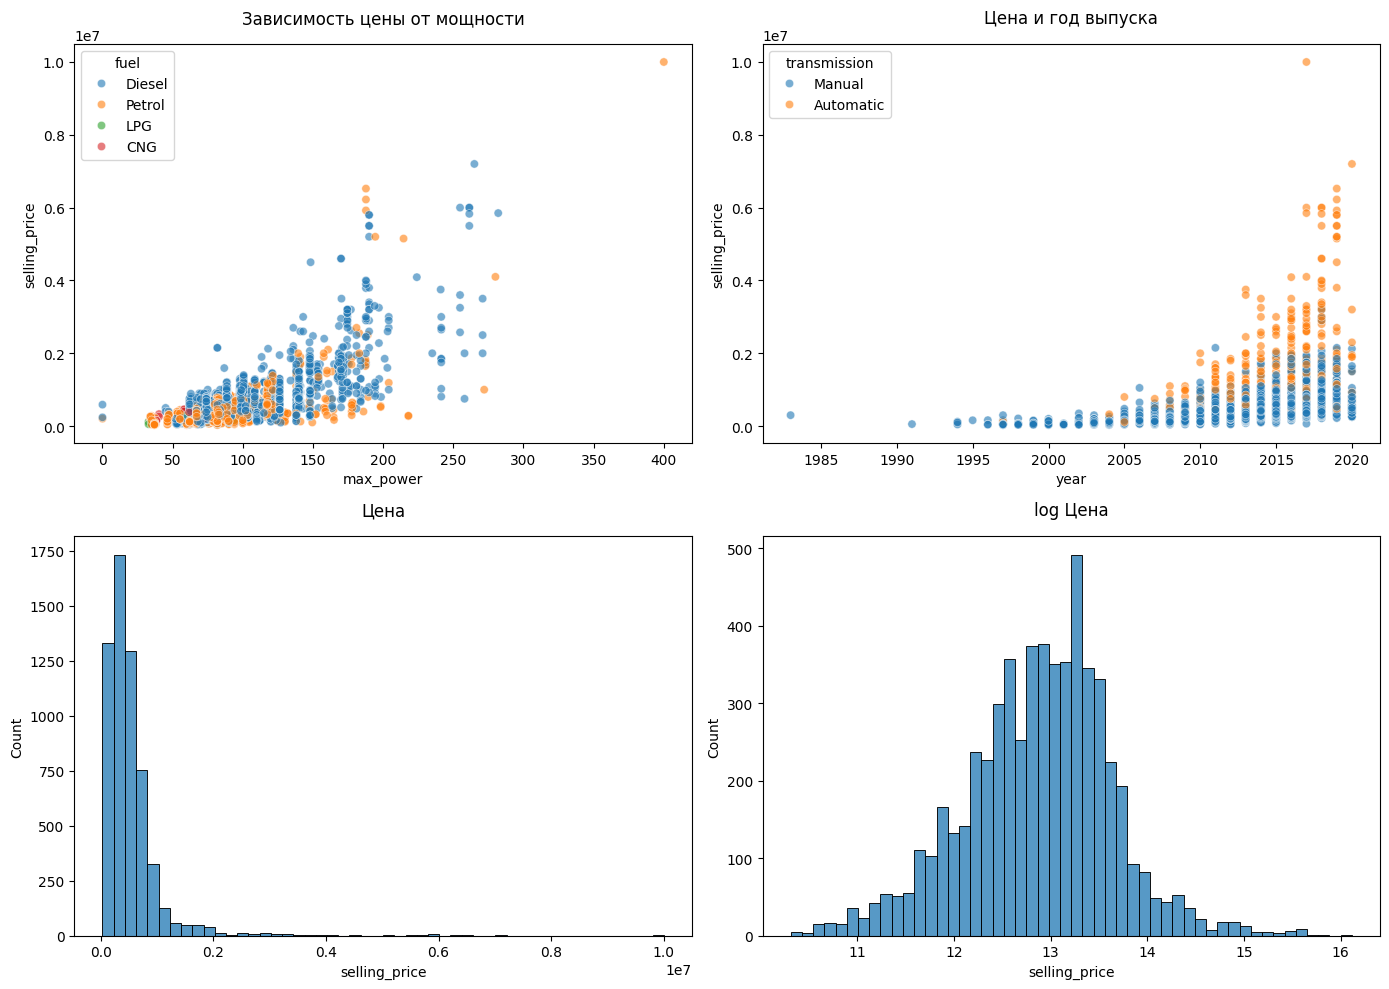

In [ ]:
# @title
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_train, x='max_power', y='selling_price', hue='fuel', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Зависимость цены от мощности', pad=15)

sns.scatterplot(data=df_train, x='year', y='selling_price', hue='transmission', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Цена и год выпуска', pad=15)

sns.histplot(df_train['selling_price'], bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Цена', pad=15)

sns.histplot(np.log1p(df_train['selling_price']), bins=50, ax=axes[1, 1])
axes[1, 1].set_title('log Цена', pad=15)

plt.tight_layout()
plt.show()

✅ **Выводы по графикам**

**Зависимость цены от мощности**

На графике видно, что с ростом мощности цена в целом увеличивается. Однако облако точек довольно широкое — при одинаковой мощности цена может сильно различаться. Дизели и бензиновые машины ведут себя похоже, но дизели показывают чуть более тесную связь.

**Цена и год выпуска**

На графике хорошо видно, что старые машины стоят дешевле, а новые — дороже. Но интереснее другое: машины с автоматической коробкой передач при одном и том же годе выпуска в среднем дороже, чем с механической. Также разброс цен у автоматов шире, особенно среди новых машин.

**Распределение цены**

На гистограмме видно, что распределение сильно скошено вправо. Большинство машин стоят недорого, при этом пик приходится на начальные ценовые диапазоны. Дальше идёт длинный и низкий хвост из дорогих автомобилей. После логарифмирования распределение стало более симметричным, что удобнее для многих моделей машинного обучения.

**Общий вывод**

Цена сильнее всего зависит от мощности, года выпуска и типа коробки передач. Автомобили на газе сильно выбиваются из общей картины, но их мало. Из-за сильной скошенности цены для прогнозирования лучше использовать не саму цену, а её логарифм.

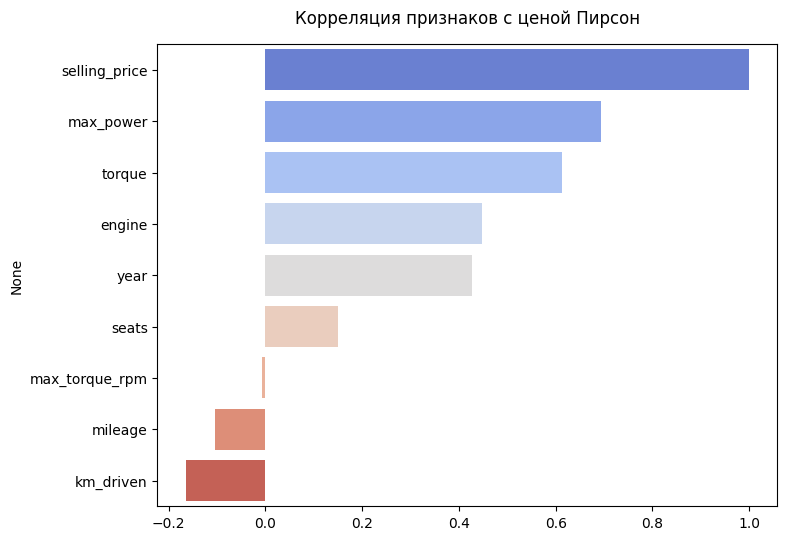

In [ ]:
# @title
corr_with_price = df_train.corr(numeric_only=True)['selling_price'].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(y=corr_with_price.index, x=corr_with_price.values, palette='coolwarm')
plt.title('Корреляция признаков с ценой Пирсон', pad=15)
plt.show()

✅ **Главный вывод:**

Для предсказания цены самые важные признаки:


- мощность `max_power`
- момент `torque`
- объём двигателя `engine`
- год выпуска `year`

Остальные можно не использовать без сильной потери качества.

# **Часть 2 (5.4 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [ ]:
numeric_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']

df_train_numeric = df_train[numeric_cols].copy()
df_test_numeric = df_test[numeric_cols].copy()

y_train = df_train['selling_price'].copy()
X_train = df_train_numeric
y_test = df_test['selling_price'].copy()
X_test = df_test_numeric

In [ ]:
assert X_train.shape == (5840, 8)

In [ ]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [ ]:
# @title
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

model=LinearRegression()
model.fit(X_train, y_train)
y_train_predict=model.predict(X_train)
y_test_predict=model.predict(X_test)

r2_train=r2_score(y_train, y_train_predict)
r2_test=r2_score(y_test, y_test_predict)

mse_train=MSE(y_train, y_train_predict)
mse_test=MSE(y_test, y_test_predict)


print("==="*15)
print("⚫ Линейная регрессия LinearRegression")
print("==="*15)
print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")
print(f"MSE train: {mse_train:.2f}")
print(f"MSE test: {mse_test:.2f}")

print("---"*15)
print(f"Разница между R2 на train и test: {r2_train - r2_test:.4f}")
if r2_train - r2_test > 0.2:
    print("---"*15)
    print("Большая разница, возможное переобучение")
    print("---"*15)
elif r2_train - r2_test < 0:
    print("---"*15)
    print("Модель на тесте лучше, чем на трейне")
    print("---"*15)
else:
    print("---"*15)
    print("Разница небольшая — переобучения нет")
    print("---"*15)

⚫ Линейная регрессия LinearRegression
R2 train: 0.6020
R2 test: 0.6028
MSE train: 114068508944.92
MSE test: 228299678155.69
---------------------------------------------
Разница между R2 на train и test: -0.0008
---------------------------------------------
Модель на тесте лучше, чем на трейне
---------------------------------------------


 ✅ Вывод: **R2 на трейне и тесте почти одинаковые. Значит модель не переучилась и одинаково хорошо работает на новых данных. Ошибка на тесте в два раза больше, но это ожидаемо,  потому что в тесте могут быть более дорогие машины.**

### **Задание 13 (0.45 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [ ]:
# @title
# a - это сумма квадратов остатков (ошибок), где y_train — реальная цена, y_pred - цена, которую предсказала модель.
# b - это общая сумма квадратов отклонений, где y_train_predict).mean() - это средняя цена всех машин в выборке.
# r2_train_manual - это коэффициент детерминации, это метрика качества подгонки.

a=((y_train-y_train_predict)**2).sum()
b=((y_train-(y_train_predict).mean())**2).sum()

r2_train_manual=1-(a/b)

print('⚫ Итог:')
print("---"*15)
print(f'R2 train  руками: {r2_train_manual:.4f}')
print("---"*15)
print(f'R2 train с помощью библиотеки: {r2_train:.4f}')


⚫ Итог:
---------------------------------------------
R2 train  руками: 0.6020
---------------------------------------------
R2 train с помощью библиотеки: 0.6020


✅ Объяснение:
$$
R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}
$$

**a**- это сумма квадратов ошибок, где
- `y_train` - реальная цена(),
- `y_pred` - цена, которую предсказала модель ().

 **b**- это общая сумма квадратов отклонений, где
 - `y_train_predict.mean()` - это средняя цена всех машин в выборке ().

**r2_train_manual** - это коэффициент детерминации, это метрика качества подгонки ().

### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [ ]:
# @title
# Реализуйте  adjusted−R2

n = X_train.shape[0]
p = X_train.shape[1]

r2_adj_train = 1 - (1 - r2_train_manual) * (n - 1) / (n - p - 1)

print('⚫ Итог:')
print("---"*15)
print(f"R2 train: {r2_train:.4f}")
print("---"*15)
print(f"Adjusted R2 train: {r2_adj_train:.4f}")

⚫ Итог:
---------------------------------------------
R2 train: 0.6020
---------------------------------------------
Adjusted R2 train: 0.6015


✅ Объяснение:
$$
R^2_{adj} = 1 - (1 - R^2) \cdot \frac{n - 1}{n - p - 1}
$$

**Adjusted R² применяется, когда нужно сравнить модели с разным количеством признаков.**

Обычный **R² всегда растёт**, когда добавляешь новые признаки, даже если они бесполезные или случайные. Из‑за этого можно ошибочно решить, что модель стала лучше.

**Adjusted R² штрафует за лишние признаки**. Если новый признак не улучшает модель по‑настоящему, **adjusted R²** может остаться тем же или даже снизиться.

В нашем случае:

- R² = 0.6020
- Adjusted R² = 0.6015

Разница очень маленькая. Это значит, что:
- Признаков не слишком много
- Каждый признак действительно вносит вклад в предсказание
- Переобучения из‑за перебора признаков нет



### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [ ]:
# @title
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)


model_scaled=LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_train_predict_scaled=model_scaled.predict(X_train_scaled)
y_test_predict_scaled=model_scaled.predict(X_test_scaled)

r2_train_scaled = r2_score(y_train, y_train_predict_scaled)
r2_test_scaled = r2_score(y_test, y_test_predict_scaled)
mse_train_scaled = MSE(y_train, y_train_predict_scaled)
mse_test_scaled = MSE(y_test, y_test_predict_scaled)


print("==="*15)
print("⚫ Стандартизация выполнена")
print("==="*15)
print("---"*15)
print(f"Средние train:")
print("---"*15)
print( X_train_scaled.mean().round(2))
print("---"*15)
print(f"Стандартное отклонение train:")
print("---"*15)
print(X_train_scaled.std().round(2))
print('\n')

print("==="*15)
print("⚫ Результаты на исходных данных")
print("==="*15)
print(f"R2 train: {r2_train:.4f}")
print("---"*15)
print(f"R2 test: {r2_test:.4f}")
print("==="*15)
print("⚫ Результаты на стандартизированных данных")
print("==="*15)
print(f"R2 train: {r2_train_scaled:.4f}")
print("---"*15)
print(f"R2 test: {r2_test_scaled:.4f}")
print('\n')

⚫ Стандартизация выполнена
---------------------------------------------
Средние train:
---------------------------------------------
year              0.0
km_driven        -0.0
mileage          -0.0
engine           -0.0
max_power         0.0
torque            0.0
seats             0.0
max_torque_rpm    0.0
dtype: float64
---------------------------------------------
Стандартное отклонение train:
---------------------------------------------
year              1.0
km_driven         1.0
mileage           1.0
engine            1.0
max_power         1.0
torque            1.0
seats             1.0
max_torque_rpm    1.0
dtype: float64


⚫ Результаты на исходных данных
R2 train: 0.6020
---------------------------------------------
R2 test: 0.6028
⚫ Результаты на стандартизированных данных
R2 train: 0.6020
---------------------------------------------
R2 test: 0.6028




✅ *Как изменилось качество модели?*

**Качество модели не изменилось, потому что линейная регрессия не чувствительна к масштабированию признаков. Стандартизация не влияет на предсказания, но помогает интерпретировать веса признаков.**

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [ ]:
# @title
# Какой признак оказался наиболее информативным в предсказании цены?
coef=model_scaled.coef_
names=X_train_scaled.columns

coef_df=pd.DataFrame({
    'feature': names,
    'coefficient': coef,
    'coefficient_abs':np.abs(coef)
}).sort_values('coefficient_abs', ascending=False)

print("==="*20)
print("⚫ Важность признаков:")
print("==="*20)
print(coef_df)

⚫ Важность признаков:
          feature    coefficient  coefficient_abs
4       max_power  287834.774586    287834.774586
0            year  161379.213153    161379.213153
5          torque   64762.007979     64762.007979
1       km_driven  -47351.367369     47351.367369
7  max_torque_rpm  -36677.636348     36677.636348
6           seats  -30766.920383     30766.920383
3          engine   22469.562698     22469.562698
2         mileage   -6763.762769      6763.762769


✅ *Какой признак оказался наиболее информативным в предсказании цены?*

**Наиболее информативным признаком оказалась мощность `max_power`. Коэффициент при стандартизированных данных составил `287 834`, что значительно выше остальных признаков. Сравниваем по модулю, потому что знак коэффициента показывает направление связи, а не силу.**

### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [ ]:
# @title
# Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
from sklearn.linear_model import Lasso

lasso_model=Lasso(random_state=42)
lasso_model.fit(X_train_scaled, y_train)

y_train_predict_lasso=lasso_model.predict(X_train_scaled)
y_test_predict_lasso=lasso_model.predict(X_test_scaled)

r2_train_lasso=r2_score(y_train, y_train_predict_lasso)
r2_test_lasso=r2_score(y_test, y_test_predict_lasso)
mse_train_lasso=MSE(y_train, y_train_predict_lasso)
mse_test_lasso=MSE(y_test, y_test_predict_lasso)

print('==='*16)
print('⚫ Lasso регрессия')
print('==='*16)
print(f'R2 train: {r2_train_lasso:.4f}')
print(f'R2 test: {r2_test_lasso:.4f}')
print('---'*15)
print(f'MSE train: {mse_train_lasso:.2f}')
print(f'MSE test: {mse_test_lasso:.2f}')

# Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.
weights_lasso = lasso_model.coef_
features = X_train_scaled.columns

print('==='*16)
print('⚫ Коэффициенты Lasso:')

for f, w in zip(features, weights_lasso):
    print('---'*15)
    print(f'{f}: {w:.4f}')
print('---'*16)

zero_weights = (weights_lasso == 0).sum()
print('==='*16)
print(f'⚫ Количество обнулённых коэффициентов: {zero_weights} из {len(weights_lasso)}')
print('==='*16)

⚫ Lasso регрессия
R2 train: 0.6020
R2 test: 0.6028
---------------------------------------------
MSE train: 114068508957.57
MSE test: 228300446641.40
⚫ Коэффициенты Lasso:
---------------------------------------------
year: 161376.9796
---------------------------------------------
km_driven: -47350.4954
---------------------------------------------
mileage: -6760.7610
---------------------------------------------
engine: 22467.6147
---------------------------------------------
max_power: 287836.3036
---------------------------------------------
torque: 64761.1261
---------------------------------------------
seats: -30763.1995
---------------------------------------------
max_torque_rpm: -36675.7867
------------------------------------------------
⚫ Количество обнулённых коэффициентов: 0 из 8


✅Вывод:
**Lasso с значением по умолчанию  `alpha=1.0` не выполнила свою главную функцию: отбор признаков. Все 8 признаков остались в модели, значит упрощения не произошло. Для реального отбора признаков нужно подбирать alpha через кросс-валидацию.**

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [ ]:
# @title
from sklearn.model_selection import GridSearchCV

param_grid={'alpha':[0.1, 0.5, 1, 5, 10, 50, 100, 200, 500, 1000]}

lasso_model=Lasso(random_state=42)

grid_search=GridSearchCV(lasso_model, param_grid, cv=10)
grid_search.fit(X_train_scaled, y_train)
best_coef = grid_search.best_estimator_.coef_

print('--'*16)
print(f'⚫ Лучший alpha: {grid_search.best_params_['alpha']:.3f}')
print('=='*16)
print(f'⚫ Лучший R2: {grid_search.best_score_:.3f}')
print('=='*16)
print('⚫ Лучший коэффициент:')
print('=='*16)
for i in best_coef:
  print('-'*20)
  print(i)
print('--'*20)
print(f'⚫ Колличество зануленных коэффициентов: {(best_coef == 0).sum()}')
print('--'*20)

--------------------------------
⚫ Лучший alpha: 1000.000
⚫ Лучший R2: 0.577
⚫ Лучший коэффициент:
--------------------
159049.117984374
--------------------
-46464.88898739865
--------------------
-3673.047057687532
--------------------
20269.9199549988
--------------------
289597.9285678987
--------------------
63829.93906628771
--------------------
-26880.816722849926
--------------------
-34835.28696723493
----------------------------------------
⚫ Колличество зануленных коэффициентов: 0
----------------------------------------


✅ *Сколько грид-сёрчу пришлось обучать моделей?*

**100 моделей.**  
Потому что перебирали 10 значений `alpha` и для каждого проводилась кросс-валидация с 10 фолдами (`cv=10`).  

✅ *Что значит каждый параметр param_grid*

param_grid = {'alpha': [0.1, 0.5, 1, 5, 10, 50, 100, 200, 500, 1000]}

- **alpha** гиперпараметр Lasso регрессии, который контролирует силу регуляризации или по другому штраф за большие коэффициенты.
- Чем больше **alpha**, тем больше коэффициенты стремятся к нулю, и тем проще становится модель.
- Значения перебираются от маленьких: слабая регуляризация до больших: сильная регуляризация, чтобы найти оптимальное по качеству.


✅ *Коэффициент регуляризации у лучшей модели. Занулились ли веса?*

**Лучший alpha = 1000.0**  
**Зануленных коэффициентов: 0**

При **alpha = 1000  Lasso не обнулила ни один вес**. Все 8 признаков остались в модели.



**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [ ]:
# @title
from sklearn.linear_model import ElasticNet

param_grid = {'alpha': [0.1, 0.5, 1, 5, 10, 50, 100, 200, 500, 1000],
              'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1]}

elastic_model = ElasticNet(random_state=42)

grid_search = GridSearchCV(elastic_model, param_grid, cv=10)
grid_search.fit(X_train_scaled, y_train)
best_coef = grid_search.best_estimator_.coef_

print('--'*16)
print(f'⚫ Лучший alpha: {grid_search.best_params_['alpha']:.3f}')
print('=='*16)
print(f'⚫ Лучший l1_ratio: {grid_search.best_params_['l1_ratio']:.3f}')
print('=='*16)
print(f'⚫ Лучший R2: {grid_search.best_score_:.3f}')
print('=='*16)
print('⚫ Лучшие коэффициенты:')
print('=='*16)
for i in best_coef:
    print(i)
    print('-'*20)
print('--'*20)
print(f'⚫ Количество зануленных коэффициентов: {(best_coef == 0).sum()}')
print('--'*20)

--------------------------------
⚫ Лучший alpha: 0.500
⚫ Лучший l1_ratio: 0.700
⚫ Лучший R2: 0.583
⚫ Лучшие коэффициенты:
138488.0577042219
--------------------
-49527.5292968203
--------------------
-3840.5752998375297
--------------------
50055.23080658984
--------------------
219627.1621072966
--------------------
93622.47874418623
--------------------
-31156.93807894817
--------------------
-19377.030700329706
--------------------
----------------------------------------
⚫ Количество зануленных коэффициентов: 0
----------------------------------------


✅ *Сколько грид-сёрчу пришлось обучать моделей?*

**600 моделей.**

- В **param_grid** 10 значений **alpha** и 6 значений **l1_ratio** комбинаций
- **cv=10** → 10 фолдов на каждую комбинацию
- Итого: 600 обучений


✅ *Какие гиперпараметры соответствуют лучшей модели?*

- **alpha = 0.5**
- **l1_ratio = 0.7**

Лучший R2 на кросс-валидации: **0.583**

### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [ ]:
# @title
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, cv=5)
sfs.fit(X_train_scaled, y_train)

selected = X_train_scaled.columns[sfs.get_support()]
print('⚫ Отобранные признаки:', selected.tolist())
print('======'*15)

X_train_sel = X_train_scaled[selected]
X_test_sel = X_test_scaled[selected]

model = LinearRegression()
model.fit(X_train_sel, y_train)

y_pred_train = model.predict(X_train_sel)
y_pred_test = model.predict(X_test_sel)

print('R2 train:', r2_score(y_train, y_pred_train))
print('--'*16)
print('R2 test:', r2_score(y_test, y_pred_test))
print('--'*16)
print('⚫ Использовано признаков:', len(selected))
print('--'*16)

⚫ Отобранные признаки: ['year', 'km_driven', 'max_power', 'torque', 'max_torque_rpm']
R2 train: 0.6005202024335956
--------------------------------
R2 test: 0.5983348781320892
--------------------------------
⚫ Использовано признаков: 5
--------------------------------



✅ **Какие признаки отобрались?**

- `year`
- `km_driven`
- `max_power`
- `torque`
- `max_torque_rpm`

| Метрика | Линейная регрессия (8 признаков) | L0 (5 признаков) |
|---------|--------------------------------|------------------|
| R2 train | 0.6020 | 0.6005 |
| R2 test | 0.6028 | 0.5983 |

- Качество почти **не изменилось**
- Модель стала **проще** осталось 5 признаков из 8
- L0 убрала: `mileage`, `engine`, `seats`

✅ Вывод:

**L0-регуляризация  отобрала самые важные признаки и убрала не нужные**, без которых качество практически не упало mileage, engine и seats.

# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



In [ ]:
# @title
# fuel, seller_type, transmission, owner
X_train_cat = X_train_scaled.copy()
X_test_cat = X_test_scaled.copy()

X_train_cat = pd.concat([X_train_cat, pd.get_dummies(df_train[['fuel', 'seller_type', 'transmission', 'owner']], drop_first=True)], axis=1)
X_test_cat = pd.concat([X_test_cat, pd.get_dummies(df_test[['fuel', 'seller_type', 'transmission', 'owner']], drop_first=True)], axis=1)

X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)
print('-'*25)
print('⚫Было признаков:', X_train_scaled.shape[1])
print('-'*25)
print('⚫Стало признаков:', X_train_cat.shape[1])
print('-'*25)

-------------------------
⚫Было признаков: 8
-------------------------
⚫Стало признаков: 18
-------------------------


In [ ]:
X_train_cat.head()

,year,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,0.139570,1.191152,0.995867,-0.373643,-0.439550,0.314704,-0.434419,-0.869673,True,False,False,True,False,True,False,False,False,False
1,0.139570,0.766619,0.428830,0.141162,0.493513,0.972840,-0.434419,-0.388098,True,False,False,True,False,True,False,True,False,False
2,-0.837167,0.883158,0.895506,-0.068879,0.066175,-1.523691,-0.434419,-0.147311,True,False,False,True,False,True,False,False,False,False
3,-1.569719,0.766619,-0.835712,-0.270682,0.009281,-1.643253,-0.434419,-2.314398,False,False,True,True,False,True,False,False,False,False
4,0.872122,-0.482007,0.177929,-0.478663,-0.191113,-0.521678,-0.434419,1.056627,False,False,True,True,False,True,False,False,False,False


### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [ ]:
# @title
# Проанализируйте столбец name. Очевидно, что эта переменная является категориальной, однако категорий в ней много.
print('--'*16)
print('⚫Уникальных названий:', df_train['name'].nunique())
print('--'*16)
print('Топ-10 самых частых названий:')
print(df_train['name'].value_counts().head(10))
print('--'*16)

# Предобработайте столбец name, чтобы избежать его удаления
df_train['name'] = df_train['name'].str.split().str[:2].str.join(' ')
df_test['name'] = df_test['name'].str.split().str[:2].str.join(' ')

top_names = df_train['name'].value_counts().head(10).index
df_train['name'] = df_train['name'].apply(lambda x: x if x in top_names else 'other')
df_test['name'] = df_test['name'].apply(lambda x: x if x in top_names else 'other')

--------------------------------
⚫Уникальных названий: 1924
--------------------------------
Топ-10 самых частых названий:
name
Maruti Swift Dzire VDI    91
Maruti Alto 800 LXI       58
Maruti Alto LXi           56
Maruti Swift VDI          48
Maruti Swift VDI BSIV     47
Maruti Alto K10 VXI       39
Maruti Ertiga VDI         37
Hyundai EON Era Plus      36
Maruti Swift Dzire VXI    34
Maruti Alto LX            34
Name: count, dtype: int64
--------------------------------


In [ ]:
print(X_train_cat.columns)

Index(['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'max_torque_rpm', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner'],
      dtype='object')


In [ ]:
assert X_train_cat.shape == (5840, 18)

In [ ]:
X_train_cat.describe()

,year,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5.840000e+03,5.840000e+03,5.840000e+03,5.840000e+03,5.840000e+03,5.840000e+03,5.840000e+03,5.840000e+03
mean,2.328122e-14,-6.205082e-17,-9.283290e-16,-1.301851e-16,3.485796e-16,6.843841e-17,2.640202e-16,1.241016e-16
std,1.000086e+00,1.000086e+00,1.000086e+00,1.000086e+00,1.000086e+00,1.000086e+00,1.000086e+00,1.000086e+00
min,-7.430137e+00,-1.231167e+00,-4.875222e+00,-1.658595e+00,-2.778531e+00,-1.716745e+00,-3.488601e+00,-2.795973e+00
25%,-5.929826e-01,-5.818974e-01,-6.224460e-01,-4.786631e-01,-6.291976e-01,-6.830314e-01,-4.344190e-01,-8.696731e-01
50%,1.395696e-01,-6.579834e-02,-1.526502e-02,-3.736430e-01,-1.911128e-01,-1.240540e-01,-4.344190e-01,-9.915301e-02
75%,8.721218e-01,4.336523e-01,7.198756e-01,1.411615e-01,3.506458e-01,4.243932e-01,-4.344190e-01,8.158396e-01
max,1.604674e+00,3.806654e+01,5.662630e+00,4.477875e+00,9.864609e+00,6.885101e+00,8.728126e+00,2.308722e+00


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [ ]:
# @title
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'name', 'seats']

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe.fit(df_train[cat_cols])

X_train_ohe = ohe.transform(df_train[cat_cols])
X_test_ohe = ohe.transform(df_test[cat_cols])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cat_cols))
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cat_cols))

X_train_full = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_test_full = pd.concat([X_test_scaled, X_test_ohe], axis=1)

print('Размер X_train_full:', X_train_full.shape)

Размер X_train_full: (5840, 36)


### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

✅ *Как корректно работать с OHE преобразованием?*

Нужно применять `drop='first'`, чтобы избежать мультиколлинеарности. Обучать на тренировочных данных, а тестовые преобразовывать с теми же столбцами. Если в тесте появилась новая категория, её нужно заменить на нули или на самую частую категорию.

✅ *Почему мы удаляем один столбец?*

Чтобы избежать линейной зависимости **мультиколлинеарности**. Если у нас есть** n** категорий, то информация о последней кодируется через комбинацию первых **n-1**. Без удаления столбцов модель становится переопределённой, и коэффициенты теряют интерпретируемость.

✅ *Корректно ли удалять неважные столбцы?*

Некорректно. В OHE каждый столбец является конкретной категорией. Нельзя просто взять и удалить те, у которых маленький вес, потому что:
- Удаление одной категории меняет смысл остальных
- Базовой категорией становится неопределённая
- Интерпретация ломается

Если категория оказалась неважной, её лучше оставить в модели, либо объединить с другой категорией до кодирования, либо использовать другой тип кодирования

### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [ ]:
# @title
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.1, 0.5, 1, 5, 10, 50, 100, 200, 500, 1000]}

ridge = Ridge(random_state=42)

grid_search = GridSearchCV(ridge, param_grid, cv=10, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

print('--'*16)
print(f'⚫ Лучший alpha: {grid_search.best_params_['alpha']:.3f}')
print('=='*16)
print(f'⚫ Лучший R2 на кросс-валидации: {grid_search.best_score_:.3f}')
print('=='*16)

best_ridge = grid_search.best_estimator_
y_test_pred_ridge = best_ridge.predict(X_test_scaled)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print(f'⚫ R2 на тесте с лучшим alpha: {r2_test_ridge:.3f}')
print('--'*20)
print('Сравнение ')
print(f'LinearRegression R2 test: {r2_test:.4f}')
print(f'Ridge (best alpha) R2 test: {r2_test_ridge:.4f}')
print(f'Разница: {r2_test_ridge - r2_test:.4f}')

--------------------------------
⚫ Лучший alpha: 1000.000
⚫ Лучший R2 на кросс-валидации: 0.583
⚫ R2 на тесте с лучшим alpha: 0.570
----------------------------------------
Сравнение 
LinearRegression R2 test: 0.6028
Ridge (best alpha) R2 test: 0.5703
Разница: -0.0325


In [ ]:
X_train.head()

,year,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
0,2014,145500,23.40,1248,74.00,190.00,5,2000.0
1,2014,120000,21.14,1498,103.52,250.00,5,2500.0
2,2010,127000,23.00,1396,90.00,22.40,5,2750.0
3,2007,120000,16.10,1298,88.20,11.50,5,500.0
4,2017,45000,20.14,1197,81.86,113.75,5,4000.0


✅Ответье на вопрос: *Удалось ли улучшить качество прогнозов?*

Нет, улучшить качество прогнозов не удалось.

Ridge регрессия показала результат на тесте **0.570**, что хуже, чем у обычной линейной регрессии **0.603**. Разница составила **-0.0325**.

Это значит, что добавление регуляризации в данном случае не помогло, а даже немного ухудшило качество. Возможно, данные не страдают от мультиколлинеарности, и обычная линейная регрессия справляется лучше.

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

# **Часть 4. | Бизнесовая (1.5 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

In [ ]:
# @title
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression

if 'y_test_pred' not in dir():
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    y_test_pred = lr_model.predict(X_test_scaled)

if X_test_scaled.shape[1] > X_train_scaled.shape[1]:
    X_test_scaled = X_test_scaled[:, :X_train_scaled.shape[1]]

best_elastic = ElasticNet(alpha=0.5, l1_ratio=0.7, random_state=42)
best_elastic.fit(X_train_scaled, y_train)
y_test_pred_elastic = best_elastic.predict(X_test_scaled)

def business_metric(y_true, y_pred):
    relative_error = abs(y_true - y_pred) / y_true
    return (relative_error <= 0.1).mean()

models_scores = {
    'LinearRegression': business_metric(y_test, y_test_pred),
    'Ridge': business_metric(y_test, y_test_pred_ridge),
    'Lasso': business_metric(y_test, y_test_predict_lasso),
    'ElasticNet': business_metric(y_test, y_test_pred_elastic)
}

print('Доля прогнозов с ошибкой не более 10%:')
for name, score in models_scores.items():
    print(f'{name}: {score:.4f}')

best_model = max(models_scores, key=models_scores.get)
print(f'\nЛучшая модель для бизнеса: {best_model} ({models_scores[best_model]:.4f})')

Доля прогнозов с ошибкой не более 10%:
LinearRegression: 0.2460
Ridge: 0.2610
Lasso: 0.2460
ElasticNet: 0.2580

Лучшая модель для бизнеса: Ridge (0.2610)


✅ Вывод:

**Ridge регрессия** оказалась лучшей для бизнеса.

### Доля прогнозов с ошибкой не более 10%

- **LinearRegression**: 0.2460
- **Ridge**: 0.2610
- **Lasso**: 0.2460
- **ElasticNet**: 0.2580


LinearRegression и Lasso показала наихудший результат, что говорит о  переобучении модели. Регуляризация Ridge и ElasticNet помогла улучшить обобщающую способность модели, повысив долю точных прогнозов.

Для бизнеса выбираем Ridge регрессию как модель с лучшей предсказательной способностью на тестовых данных.

### **Задание 24 (0.75 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



In [ ]:
def custom_metric(y_true, y_pred):
    correct = 0
    total = len(y_true)

    for i in range(total):
        error = abs(y_true[i] - y_pred[i]) / y_true[i]

        if y_pred[i] >= y_true[i]:
            if error <= 0.1:
                correct += 1
        else:
            if error <= 0.05:
                correct += 1

    return correct / total

custom_scores = {
    'LinearRegression': custom_metric(y_test, y_test_pred),
    'Ridge': custom_metric(y_test, y_test_pred_ridge),
    'Lasso': custom_metric(y_test, y_test_predict_lasso),
    'ElasticNet': custom_metric(y_test, y_test_pred_elastic)
}

print('Доля прогнозов с учётом асимметрии:')
for name, score in custom_scores.items():
    print(f'{name}: {score:.4f}')

best_custom = max(custom_scores, key=custom_scores.get)
print(f'\nЛучшая модель: {best_custom} ({custom_scores[best_custom]:.4f})')

Доля прогнозов с учётом асимметрии (недопрогноз строже):
LinearRegression: 0.1870
Ridge: 0.1960
Lasso: 0.1870
ElasticNet: 0.1840

Лучшая модель: Ridge (0.1960)


✅ **Ridge регрессия снова оказалась лучшей!**

#**Сохранения лучшей модели (Ridge)**

In [ ]:
from sklearn.linear_model import Ridge
import joblib
from google.colab import files

best_ridge = Ridge(alpha=1000, random_state=42)
best_ridge.fit(X_train_scaled, y_train)

joblib.dump(best_ridge, 'model.pkl')
print("✅ model.pkl сохранён")

feature_cols = X_train_scaled.columns.tolist()
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ feature_cols.pkl сохранён")

files.download('model.pkl')
files.download('feature_cols.pkl')

print(f"✅ Модель сохранена. Признаков: {len(feature_cols)}")
print(f"Признаки: {feature_cols}")

# Сохраняем scaler
joblib.dump(scaler, 'scaler.pkl')
files.download('scaler.pkl')
print("✅ Scaler сохранён!")

✅ model.pkl сохранён
✅ feature_cols.pkl сохранён


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Модель сохранена! Признаков: 8
Признаки: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Scaler сохранён!


In [ ]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


# **Часть 5 (12 баллов) | Реализация сервиса на FastAPI**

### **Задание 25 (9 баллов)**

Cделайте с помощью FastAPI сервис, который с точки зрения пользователя реализует две функции:

1. на вход в формате json подаются признаки одного объекта, на выходе сервис выдает предсказанную стоимость машины
2. на вход подается csv-файл с признаками тестовых объектов, на выходе получаем файл с +1 столбцом - предсказаниями на этих объектах

С точки зрения реализации это означает следующее:
- средствами pydantic должен быть описан класс базового объекта
- класс с коллецией объектов
- метод post, который получает на вход один объект описанного класса
- метод post, который получает на вход коллекцию объектов описанного класса

Шаблон для сервисной части дан ниже. Код необходимо дополнить и оформить в виде отдельного .py-файла.

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List

app = FastAPI()


class Item(BaseModel):
    name: str
    year: int
    selling_price: int
    km_driven: int
    fuel: str
    seller_type: str
    transmission: str
    owner: str
    mileage: str
    engine: str
    max_power: str
    torque: str
    seats: float


class Items(BaseModel):
    objects: List[Item]


# Функция предобработки: из Item в вектор признаков X
def preprocess_item(item: Item):
    # Создаём DataFrame из одного элемента
    df = pd.DataFrame([item.dict()])
    # Извлекаем числа из строковых колонок
    df['mileage'] = df['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
    df['engine'] = df['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
    df['max_power'] = df['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)
    # torque: вытаскиваем все числа, первое = torque, последнее = max_torque_rpm
    torque_numbers = df['torque'].str.findall(r'(\d+\.?\d*)')
    df['torque'] = torque_numbers.apply(lambda x: float(x[0]) if x else 0)
    df['max_torque_rpm'] = torque_numbers.apply(lambda x: float(x[-1]) if x else 0)
    # Берём нужные 8 признаков в том же порядке, что и при обучении
    feature_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']
    X = df[feature_cols].fillna(0).values  # пропусков быть не должно, но на всякий случай
    X_scaled = scaler.transform(X)
    return X_scaled

@app.post("/predict_item")
def predict_item(item: Item) -> float:
    X = preprocess_item(item)
    pred = model.predict(X)[0]
    return float(pred)

@app.post("/predict_items")
def predict_items(items: List[Item]) -> List[float]:
    preds = []
    for it in items:
        X = preprocess_item(it)
        preds.append(float(model.predict(X)[0]))
    return preds

Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

### **Задание 26 (3 балла). Оформление результатов**

**Результаты вашей работы** необходимо разместить в своем GitHub-репозитории, который создали в первой части ДЗ-1. Под результатами понимаем следующее:
* ``.ipynb``-ноутбук со всеми проведёнными вами экспериментами (output'ы ячеек, разумеется, сохранить)
* ``.py``-файл с реализацией сервиса
* ``.pickle``-файл с сохранёнными весами модели, коэффициентами скейлинга и прочими числовыми значениями, которые могут понадобиться для инференса
* ``.md``-файл с выводами про проделанной вами работе:
    * что было сделано
    * с какими результатами
    * что дало наибольший буст в качестве
    * что сделать не вышло и почему (это нормально, даже хорошо😀)
    * демо работы сервиса

**За что могут быть сняты баллы в этом пункте:**
* за отсутствие любого из упомянутых файлов ( ``.pickle``-файла с весами использованной модели, ``.py``-файла с реализацией сервиса, ``.ipynb``-ноутбука, ``.md``-файла)
* за недостаточную аналитику в ``.md``-файле
* за оформление и логику кода (в определённом смысле это тоже элемент оформления решения)

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)



## 🎉 **Уффф… Готово!** 🎉

###**Я очень тщательно подошла к каждому этапу работы: от первичного анализа данных и очистки текстовых признаков до обучения моделей и развёртывания сервиса. Было непросто, но очень интересно!!!**

###**Честно говоря, я сильно устала, потому что старалась не только написать работающий код, но и сделать проект аккуратным, понятным и приятным для проверяющего.**

###**Поэтому я хочу поблагодарить за такую возможность.**
###**Домашка мне очень понравилась** ❤

###😎😎😎 **И да, теперь я с чистой совестью хочу себя наградить, может ☕︎ чашкой хорошего кофе)))**

###**Спасибо за внимание к моей работе**🫰🫰🫰





P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!